In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

os.chdir('../../..')
os.getcwd()


'/home/akshey/Desktop/PhD/Code_repositories/bundlenet_results'

# BunDLe Net manifold on all rats


bundlenet_rat_achilles


<IPython.core.display.Javascript object>


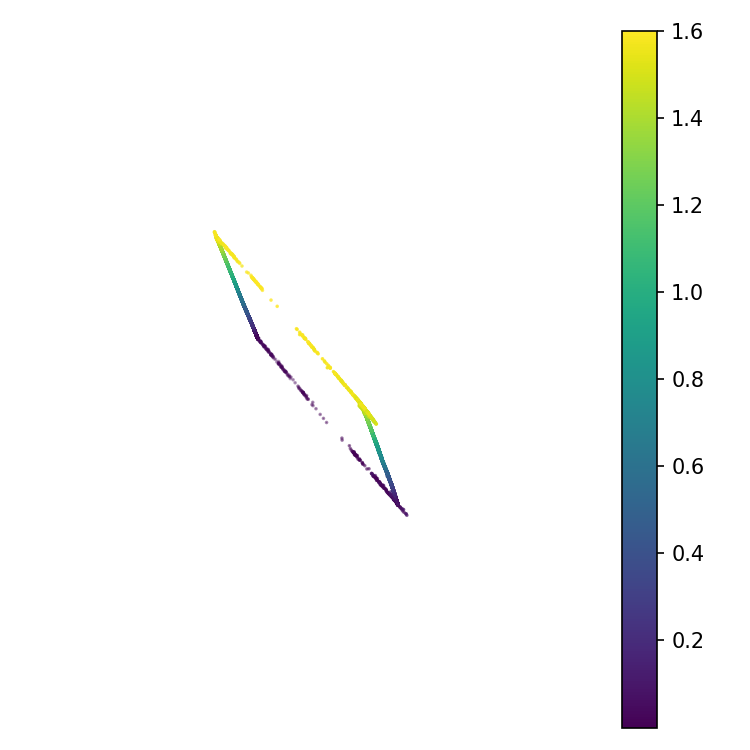

<IPython.core.display.Javascript object>


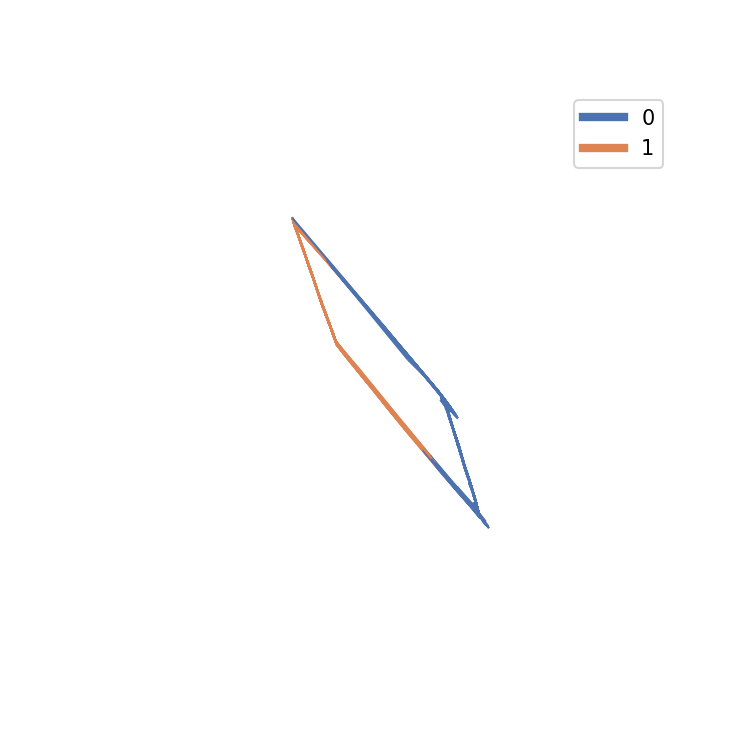

bundlenet_rat_gatsby


<IPython.core.display.Javascript object>


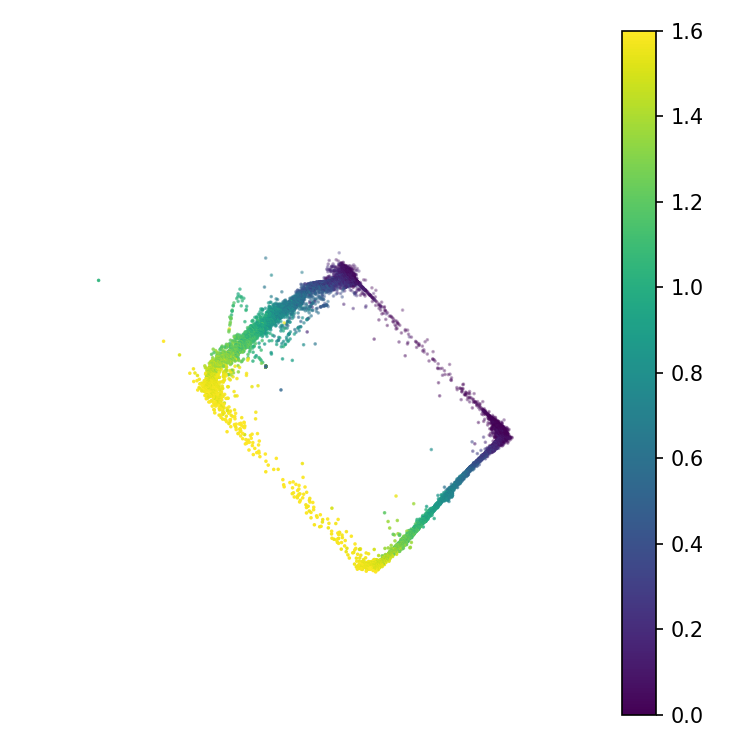

<IPython.core.display.Javascript object>


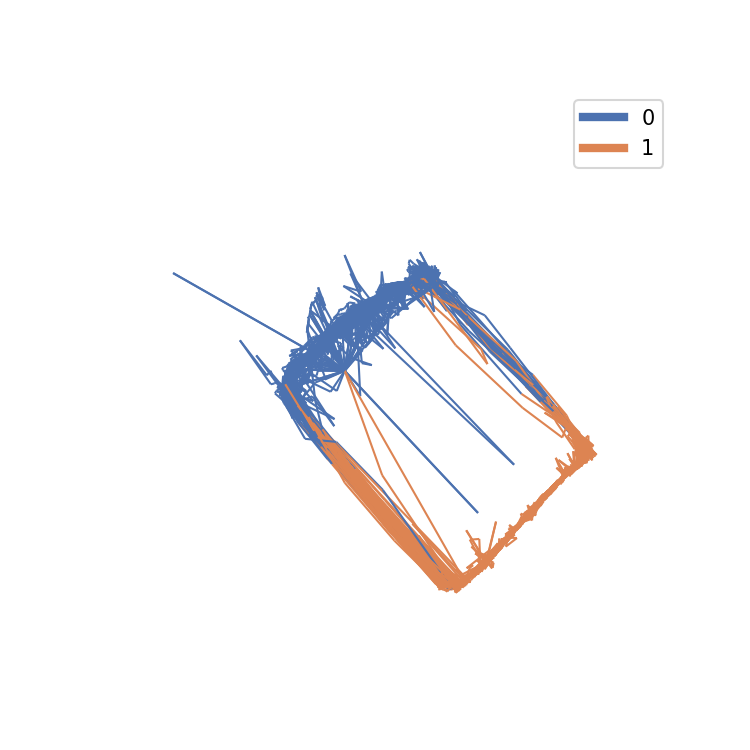

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/ncmcm/visualisers/latent_space.py:186: RuntimeWarning: divide by zero encountered in scalar divide
  kwargs.setdefault('arrow_length_ratio', 0.01 / np.linalg.norm(d))


bundlenet_rat_cicero


<IPython.core.display.Javascript object>


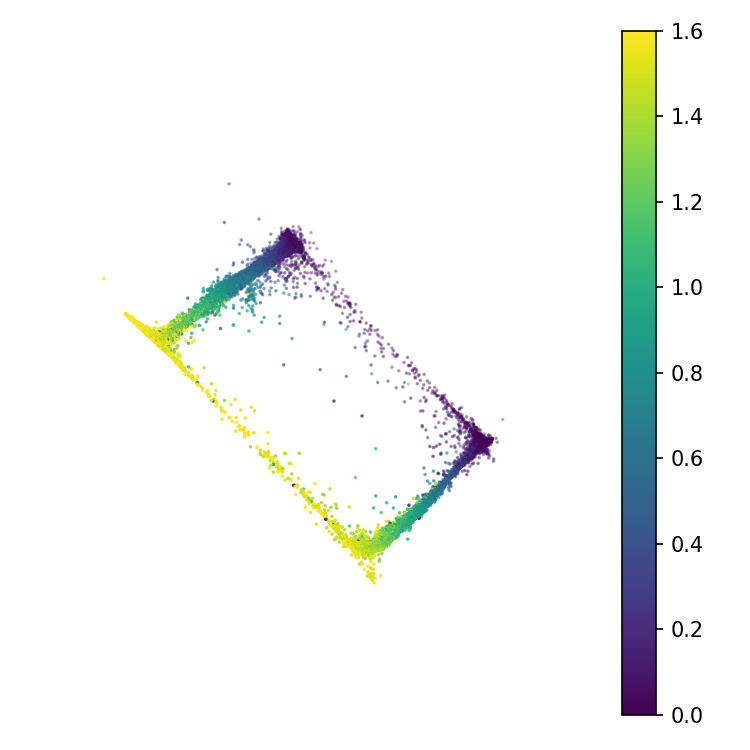

<IPython.core.display.Javascript object>


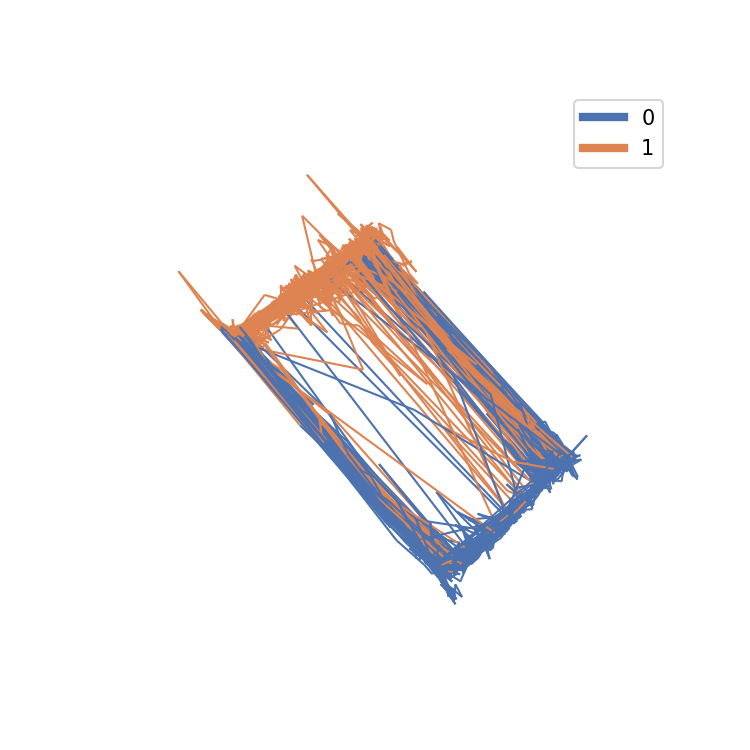

bundlenet_rat_buddy


<IPython.core.display.Javascript object>


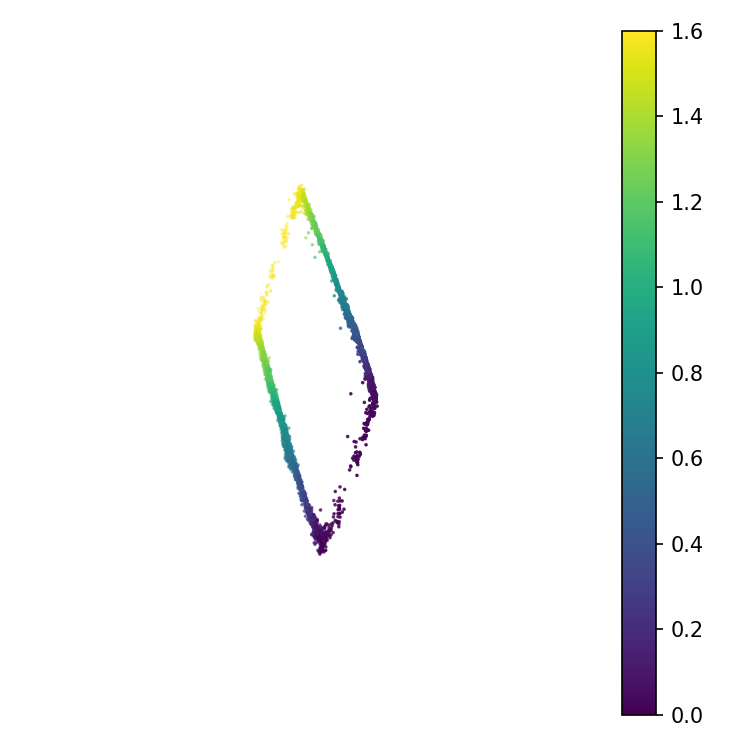

<IPython.core.display.Javascript object>


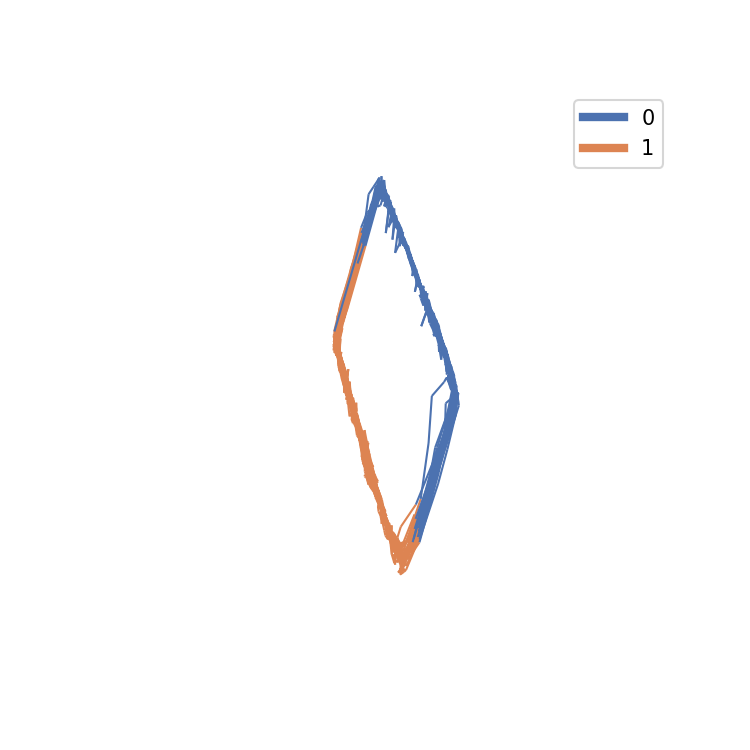

In [3]:
%matplotlib notebook
rat_names = ['achilles', 'gatsby', 'cicero', 'buddy']
for rat_name in rat_names:
    for algorithm in ['bundlenet']:#, 'cebra_hybrid', 'cca_tde', 'pca_tde', 'rrr_tde', 'autoencoder', 'dynamics_autoencoder' ]:
        print(f'{algorithm}_rat_{rat_name}')
        y_ = np.loadtxt(f'data/generated/embeddings/rat/y0__{algorithm}_rat_{rat_name}')
        b_ = np.loadtxt(f'data/generated/embeddings/rat/b__{algorithm}_rat_{rat_name}')

        # Continuous variable plotting
        fig = plt.figure(figsize=(5,5))
        ax = plt.axes(projection='3d')
        ax.axis('off')
        y_pts = ax.scatter(y_[:, 0], y_[:, 1], y_[:, 2], c=b_[:, 0], s=0.5)
        plt.colorbar(y_pts)
        plt.tight_layout()

        # Discrete variable plotting
        fig = plt.figure(figsize=(5,5))
        ax = plt.axes(projection='3d')
        vis = LatentSpaceVisualiser(
            y=y_,
            b=b_[:, 1].astype(int),
            b_names=['0', '1'],

        )
        fig, ax = vis._plot_ps(fig, ax, arrow_length_ratio=0.0001)
        plt.show()

# Different embedding techniques on rat 1

<IPython.core.display.Javascript object>


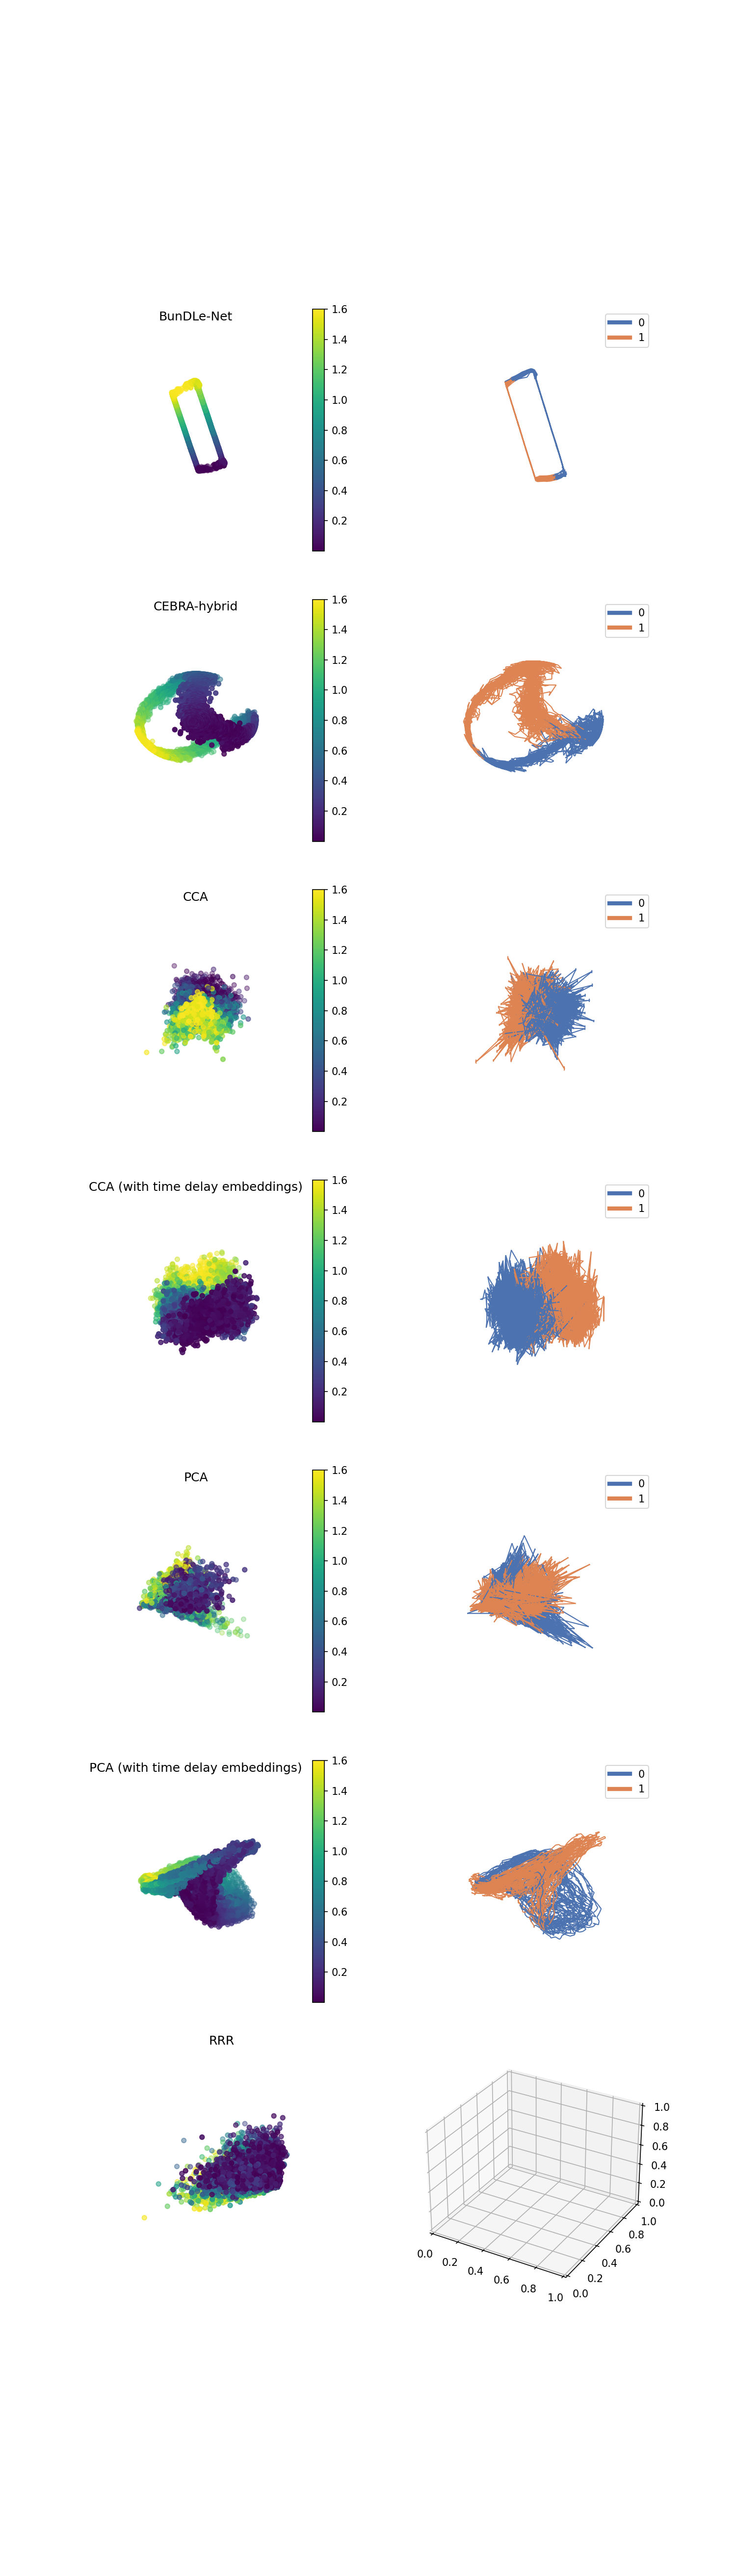

IndexError: list index out of range

In [4]:
fig, ax = plt.subplots(7,2,figsize=(10,35),subplot_kw=dict(projection='3d'))
rat_name = rat_names[0]
elev = [-11, 8, 42, 25, -7, -21]
azim = [-45,56,-16,-25,-10,-1]
algorithms = [
    'bundlenet', 
    'cebra_hybrid', 
    'cca', 
    'cca_tde', 
    'pca', 
    'pca_tde', 
    'rrr', 
    'rrr_tde', 
    'autoencoder', 
    'dynamics_autoencoder' 
]
titles = [
    'BunDLe-Net', 
    'CEBRA-hybrid', 
    'CCA',
    'CCA (with time delay embeddings)', 
    'PCA',
    'PCA (with time delay embeddings)', 
    'RRR',
    'RRR (with time delay embeddings)', 
    'autoencoder', 
    'dynamics_autoencoder']

for i, (algorithm, title) in enumerate(zip(algorithms,titles)):
    y_ = np.loadtxt(f'data/generated/embeddings/rat/y0__{algorithm}_rat_{rat_name}')
    b_ = np.loadtxt(f'data/generated/embeddings/rat/b__{algorithm}_rat_{rat_name}')

    pcm = ax[i, 0].scatter(y_[:, 0], y_[:, 1], y_[:, 2], c=b_[:,0])
    ax[i, 0].set_title(title)
    ax[i, 0].grid(False)
    ax[i, 0].axis('off')
    ax[i, 0].view_init(elev=elev[i], azim=azim[i], roll=0)
    fig.colorbar(pcm, ax=ax[i, 0])
    
    ax[i, 1].view_init(elev=elev[i], azim=azim[i], roll=0)
    vis = LatentSpaceVisualiser(
        y=y_,
        b=b_[:, 1].astype(int),
        b_names=['0', '1'],
        
    )
    vis._plot_ps(fig, ax[i,1], arrow_length_ratio=0.01)
    
    
plt.grid(False)
plt.axis('off')
plt.show()

<IPython.core.display.Javascript object>


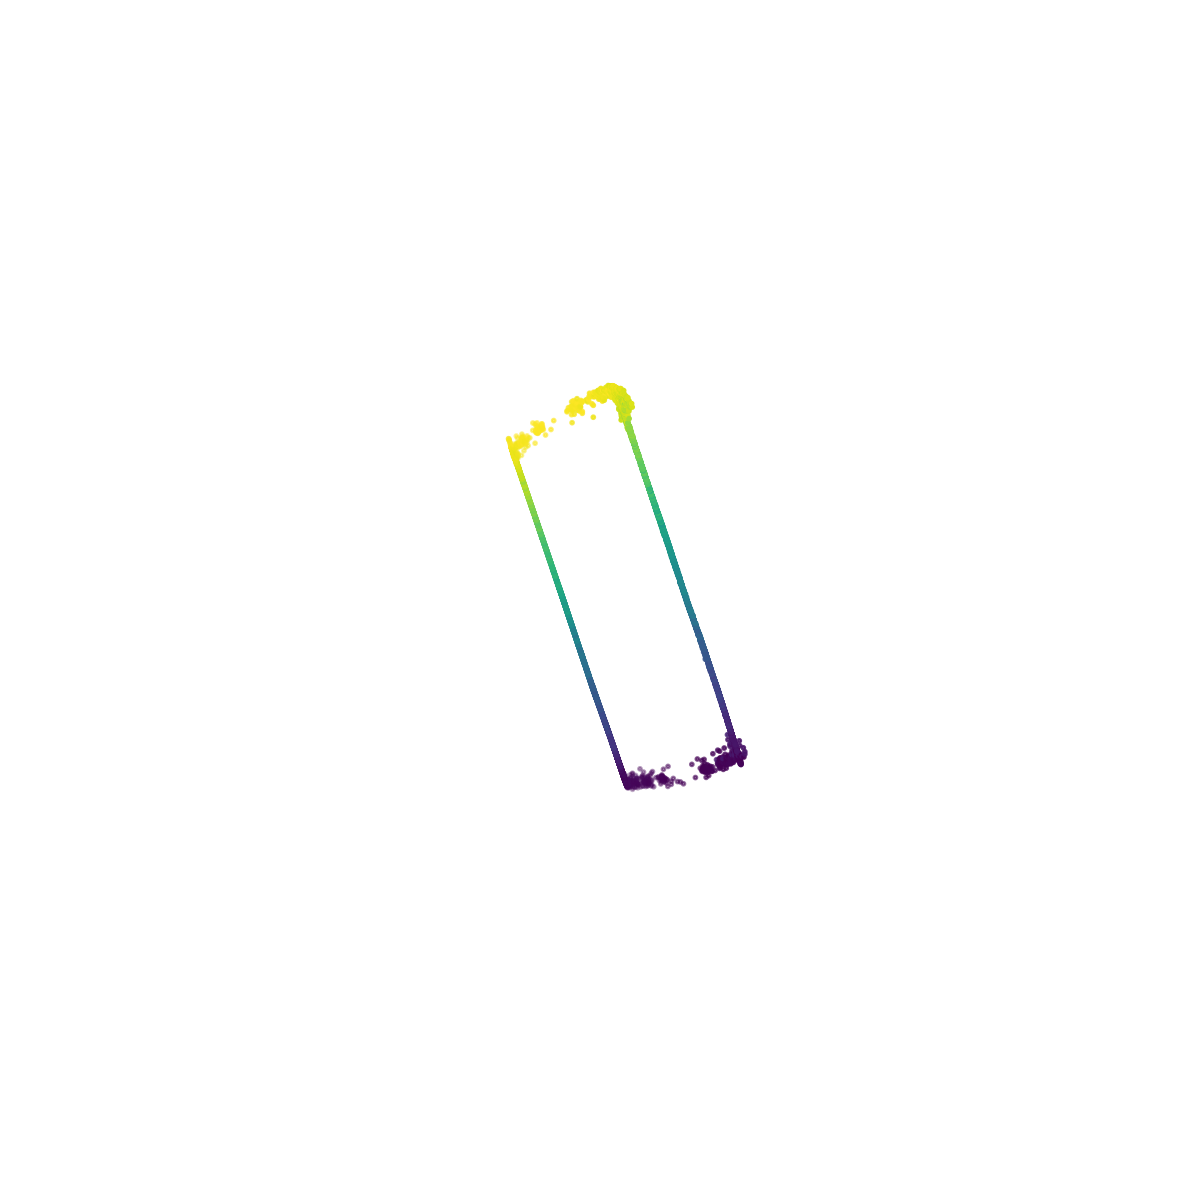

<IPython.core.display.Javascript object>


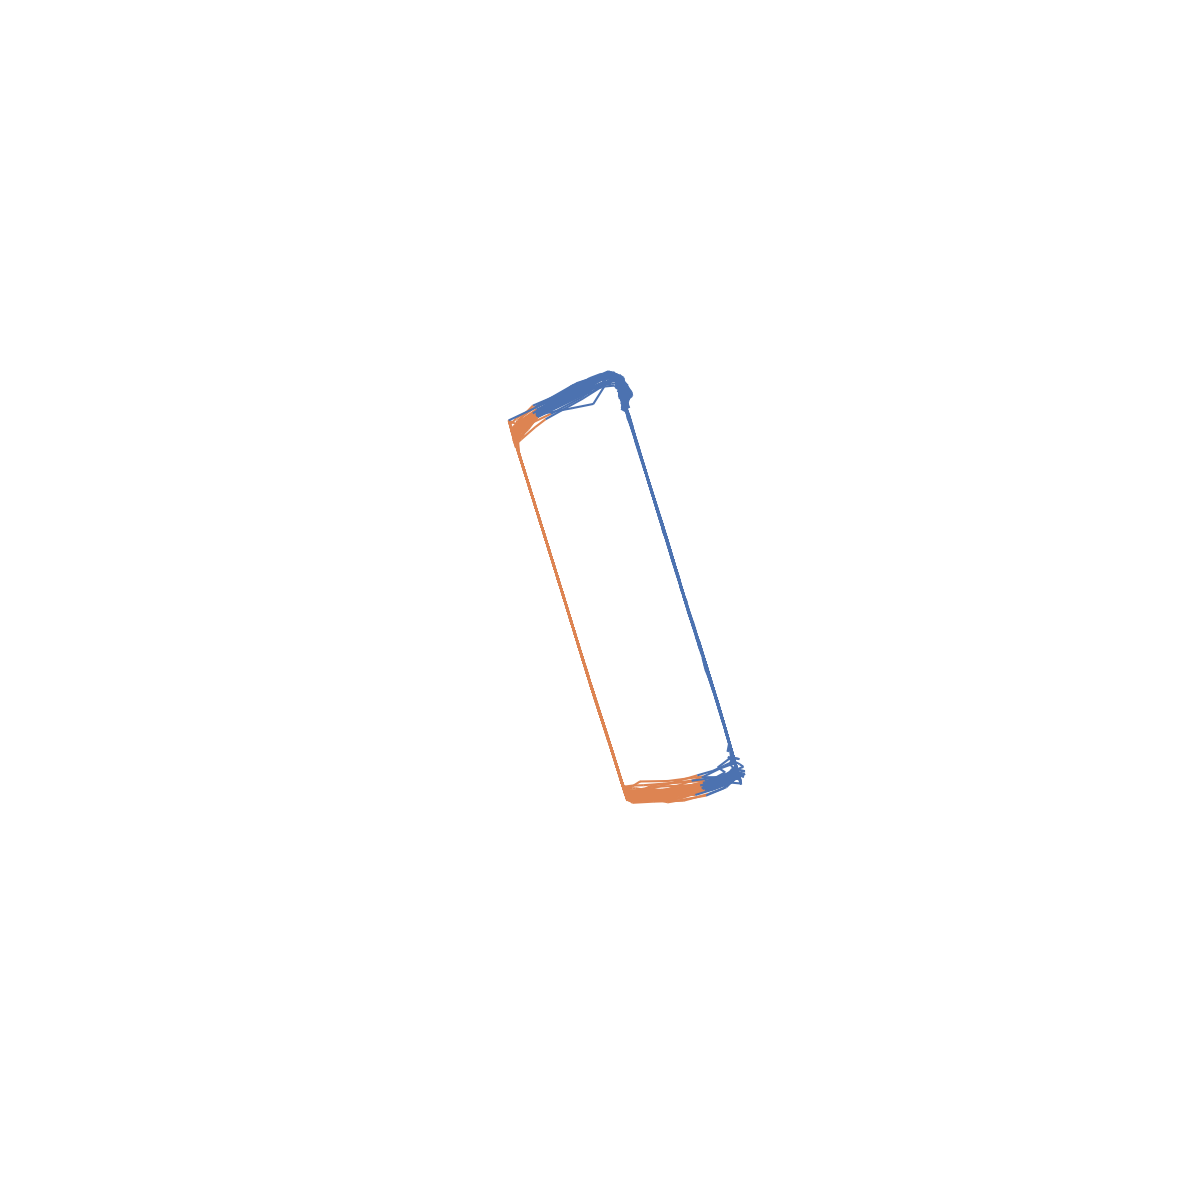

<IPython.core.display.Javascript object>


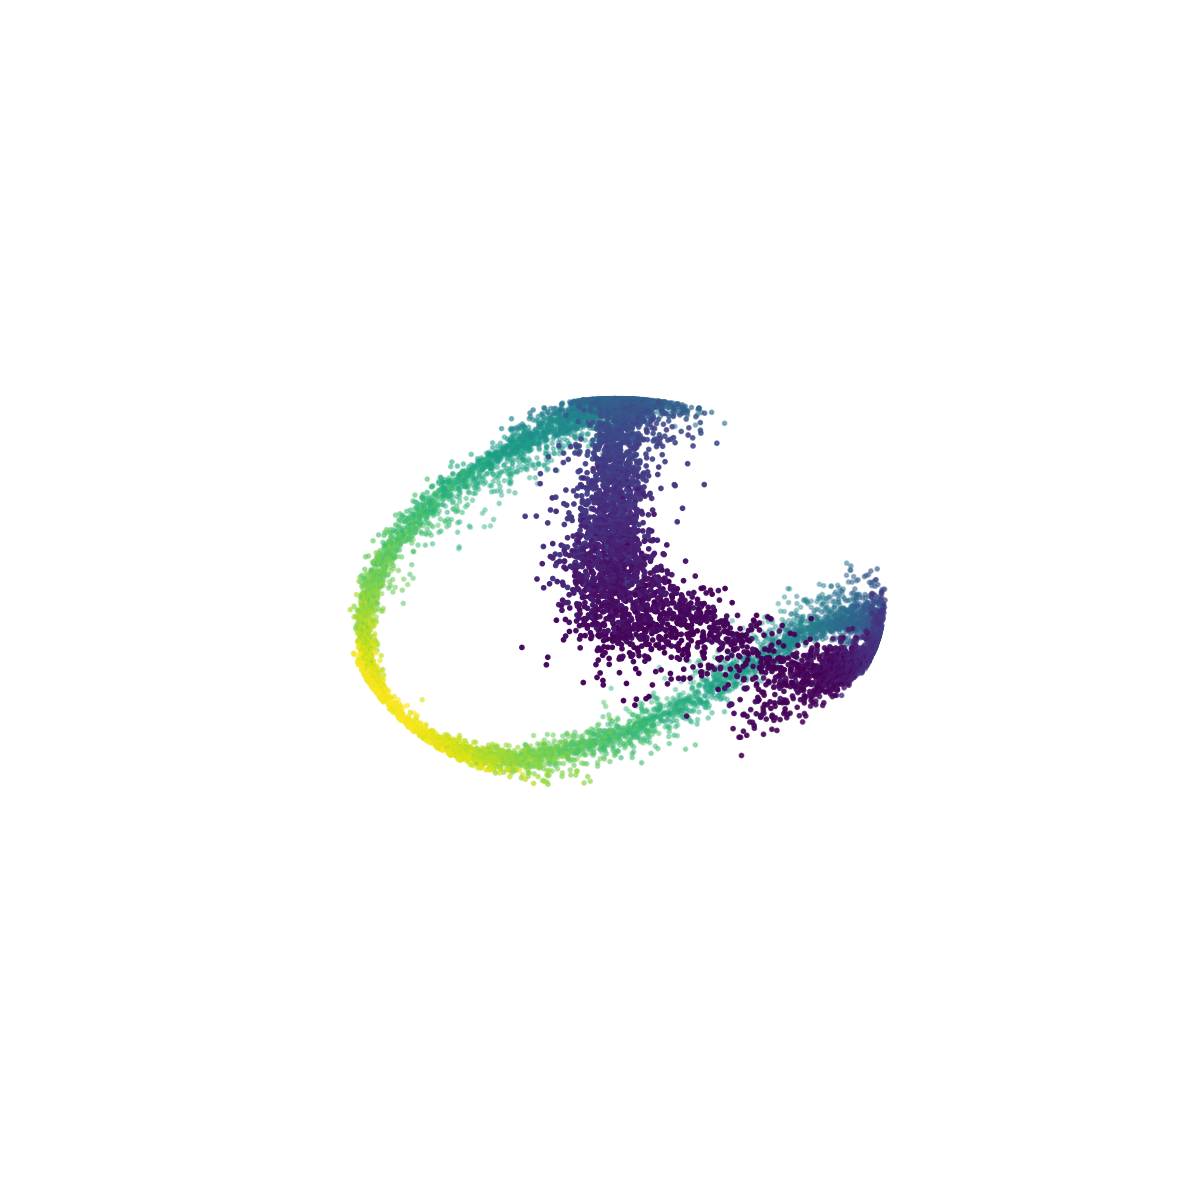

<IPython.core.display.Javascript object>


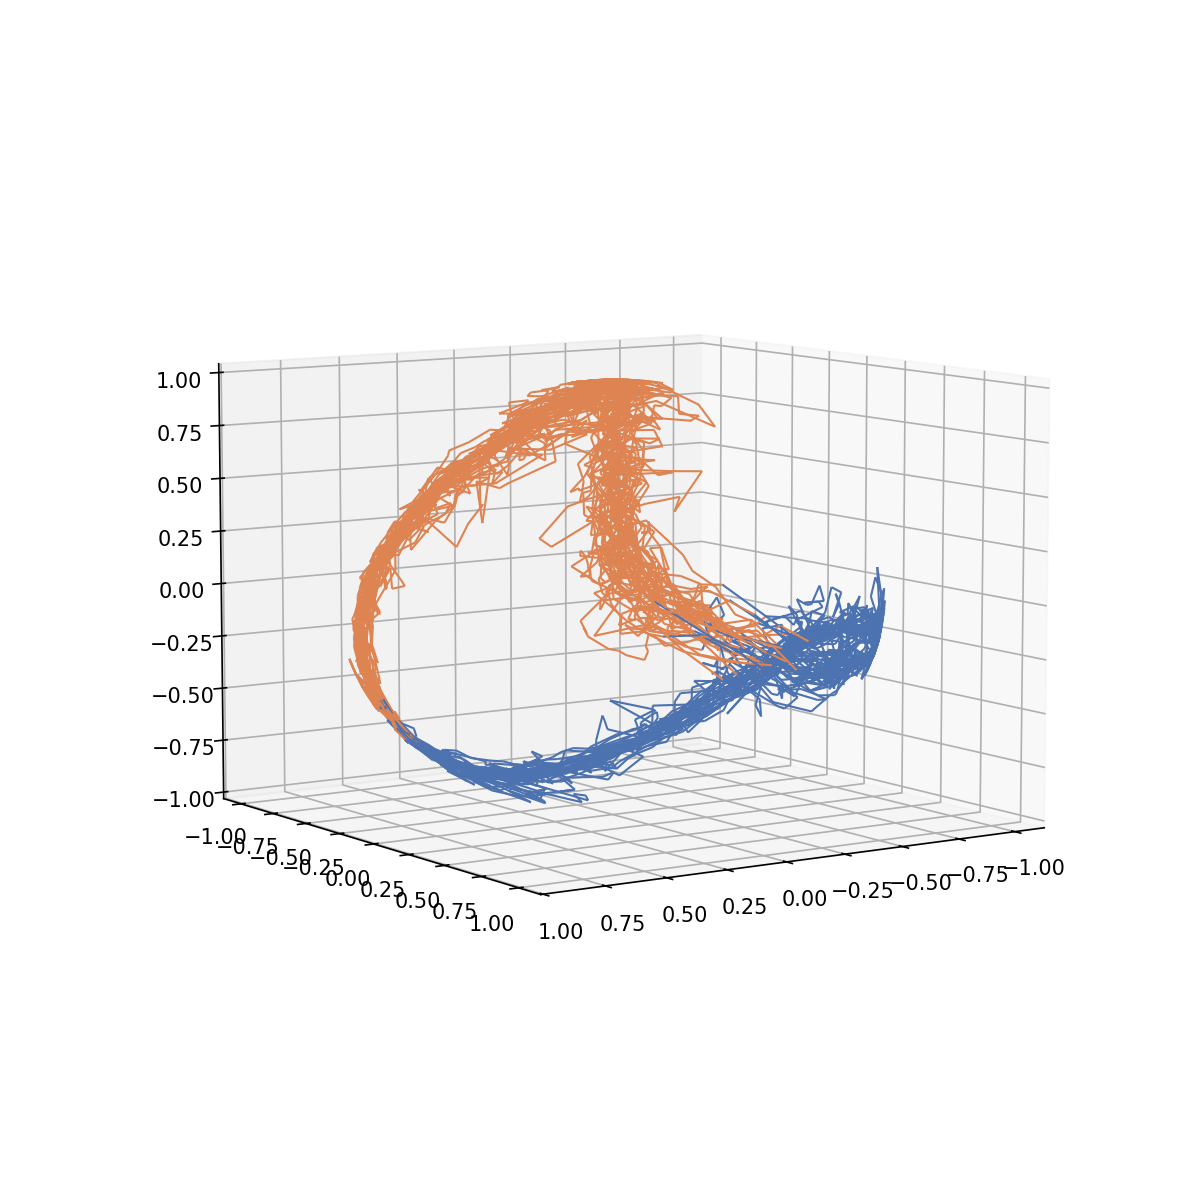

KeyboardInterrupt: 

In [16]:
# Code to save figures for paper
elev = [-11, 8, 42, 25, -7, -21]
azim = [-45,56,-16,-25,-10,-1]
algorithms = ['bundlenet', 'cebra_hybrid', 'cca_tde', 'pca_tde', 'rrr_tde', 'autoencoder', 'dynamics_autoencoder' ]
titles = ['BunDLe-Net', 'CEBRA-hybrid', 'CCA (with time delay embeddings)', 'PCA (with time delay embeddings)', 'RRR (with time delay embeddings)', 'autoencoder', 'dynamics_autoencoder']
for i, (algorithm, title) in enumerate(zip(algorithms, titles)):
    #1
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')
    
    y_ = np.loadtxt(f'data/generated/embeddings/rat/y0__{algorithm}_rat_{rat_name}')
    b_ = np.loadtxt(f'data/generated/embeddings/rat/b__{algorithm}_rat_{rat_name}')

    pcm = ax.scatter(y_[:, 0], y_[:, 1], y_[:, 2], c=b_[:,0], s=3)
    ax.grid(False)
    ax.axis('off')
    ax.view_init(elev=elev[i], azim=azim[i], roll=0)
    plt.savefig(f'rat_results/embedding_algorithms/figures/rat_{rat_name}_embedding_{algorithms[i]}_position_labels', transparent=True, bbox_inches="tight", dpi=300)
    
    #2
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')
    ax.view_init(elev=elev[i], azim=azim[i], roll=0)
    vis = LatentSpaceVisualiser(
        y=y_,
        b=b_[:, 1].astype(int),
        b_names=['0', '1'],
        legend=False
    )
    vis._plot_ps(fig, ax, arrow_length_ratio=0.01)
    
    
    
    
    plt.savefig(f'rat_results/embedding_algorithms/figures/rat_{rat_name}_embedding_{algorithms[i]}_direction_labels', transparent=True, bbox_inches="tight", dpi=300)